# Feature Engineering

Partimos del dataset limpio `matches_clean.csv` (generado por `eda.ipynb`): nulos imputados con KNN, banderas `*_Ausente`, `Time_hora` y columnas de baja cobertura eliminadas. Aquí se construyen las features de historial (media móvil de los últimos 5 partidos), la de squad (`DIF_sq_top11`) y la selección con `mutual_info_classif`, para exportar `dataset_final.csv`.

Única excepción: las cuotas medias del mercado 1X2 (`AvgH/AvgD/AvgA`) no pasan por la limpieza (en `eda.ipynb` quedan como banderas `*_Ausente`); se re-imputan aquí con KNN sobre el crudo `matches_sq.csv`, igual que en el flujo original.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

CUOTAS = ['B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'BFH', 'BFD', 'BFA', '1XBH', '1XBD', '1XBA', 'BFEH', 'BFED', 'BFEA', 'BFE>2.5', 'BFE<2.5', 'BFEAHH', 'BFEAHA', 'BFCH', 'BFCD', 'BFCA', '1XBCH', '1XBCD', '1XBCA', 'BFECH', 'BFECD', 'BFECA', 'BFEC>2.5', 'BFEC<2.5', 'BFECAHH', 'BFECAHA', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'CLH', 'CLD', 'CLA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA']

df_clean = pd.read_csv("../scripts/data/matches_clean.csv")
df = pd.read_csv("../scripts/data/matches_sq.csv", usecols=["AvgH", "AvgD", "AvgA"])
df_clean.shape


/tmp/ipykernel_145533/3157817119.py:9: DtypeWarning: Columns (0: Referee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("../scripts/data/matches_clean.csv")


(30182, 136)

## Feature historial: forma de los últimos 5 partidos

Convertimos cada partido en 2 registros (local y visitante) con las stats **desde el lado del equipo**,
calculamos la media móvil de los **últimos 5 partidos** (no incluimos el partido vivo)
y unimos de vuelta como `H_*_5` (forma del local) y `A_*_5` (forma del visitante).

In [3]:
df_r = df_clean.reset_index().rename(columns={'index': 'match_id'})
df_r['Date_dt'] = pd.to_datetime(df_r['Date'], dayfirst=True, errors='coerce')
df_r = df_r.sort_values(['Date_dt', 'match_id']).reset_index(drop=True)
df_r['seq'] = np.arange(len(df_r))

ev_rows = []
for lado, col in [('H', 'HomeTeam'), ('A', 'AwayTeam')]:
    e = df_r.copy()
    local = e['HomeTeam'] == e[col]
    e['Team']   = e[col]
    e['GF']     = np.where(local, e['FTHG'], e['FTAG'])
    e['GA']     = np.where(local, e['FTAG'], e['FTHG'])
    ganador = 'H' if lado == 'H' else 'A'
    e['WinRate'] = (e['FTR'] == ganador).astype(float)
    e['Pts']    = np.select([e['FTR'] == ganador, e['FTR'] == 'D'], [3, 1], 0)
    e['SGF']    = np.where(local, e['HS'], e['AS'])
    e['SGA']    = np.where(local, e['AS'], e['HS'])
    e['SOTF']   = np.where(local, e['HST'], e['AST'])
    e['SOTA']   = np.where(local, e['AST'], e['HST'])
    e['CF']     = np.where(local, e['HC'], e['AC'])
    e['CA']     = np.where(local, e['AC'], e['HC'])
    e['FF']     = np.where(local, e['HF'], e['AF'])
    e['FA']     = np.where(local, e['AF'], e['HF'])
    e['CardF']  = np.where(local, e['HY'] + e['HR'], e['AY'] + e['AR'])
    e['CardA']  = np.where(local, e['AY'] + e['AR'], e['HY'] + e['HR'])
    e['CS']     = (e['GA'] == 0).astype(int)
    e['lado']   = lado
    cols = ['match_id','seq','Team','lado','GF','GA','Pts','WinRate','SGF','SGA','SOTF','SOTA','CF','CA','FF','FA','CardF','CardA','CS']
    ev_rows.append(e[e['Team'].notna()][cols])
ev = pd.concat(ev_rows, ignore_index=True)
ev = ev.sort_values(['Team', 'seq']).reset_index(drop=True)

ROLL = ['GF','GA','Pts','WinRate','SGF','SGA','SOTF','SOTA','CF','CA','FF','FA','CardF','CardA','CS']
for f in ROLL:
    ev[f + '_5'] = ev.groupby('Team')[f].transform(lambda s: s.rolling(5, min_periods=1).mean().shift(1))

df_clean['match_id'] = np.arange(len(df_clean))
h = ev[ev['lado'] == 'H'][['match_id'] + [f + '_5' for f in ROLL]]
h.columns = ['match_id'] + ['H_' + f + '_5' for f in ROLL]
a = ev[ev['lado'] == 'A'][['match_id'] + [f + '_5' for f in ROLL]]
a.columns = ['match_id'] + ['A_' + f + '_5' for f in ROLL]
df_clean = df_clean.merge(h, on='match_id', how='left').merge(a, on='match_id', how='left').drop(columns=['match_id'])
print('Features rolling agregadas:', 2 * len(ROLL))
print('Sin historial (H_GF_5 NaN):', int(df_clean['H_GF_5'].isna().sum()), '| (A_GF_5 NaN):', int(df_clean['A_GF_5'].isna().sum()))

/tmp/ipykernel_145533/3825597628.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_r = df_clean.reset_index().rename(columns={'index': 'match_id'})
/tmp/ipykernel_145533/3825597628.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_r['Date_dt'] = pd.to_datetime(df_r['Date'], dayfirst=True, errors='coerce')
/tmp/ipykernel_145533/3825597628.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.co

Features rolling agregadas: 30
Sin historial (H_GF_5 NaN): 132 | (A_GF_5 NaN): 148


/tmp/ipykernel_145533/3825597628.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['match_id'] = np.arange(len(df_clean))


## Imputación de las feature historial
Los NaN de `H_*_5`/`A_*_5` (equipos sin 5 partidos previos) se imputan con la media de esa liga y temporada, el valor típico de la media móvil del equipo.

In [4]:
ROLL5 = [c for c in df_clean.columns if c.endswith('_5')]
print('NaN en rolling antes:', int(df_clean[ROLL5].isna().sum().sum()))
for c in ROLL5:
    medias = df_clean.groupby(['Div', 'Season'])[c].transform('mean')
    df_clean[c] = df_clean[c].fillna(medias)
print('NaN en rolling después:', int(df_clean[ROLL5].isna().sum().sum()))

NaN en rolling antes: 4200
NaN en rolling después: 0


## Atributos al finalizar
Eliminamos `FTHG, FTAG, HTHG, HTAG, HTR, HS, AS, HST, AST, HF, AF, HC, AC, HY, AY, HR, AR` que se conocen al finalizar el partido. Su único rol fue calcular los historiales `H_*_5`/`A_*_5`. 

In [5]:
finalizar = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST',
                    'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']

columnas_a_borrar = [col for col in finalizar if col in df_clean.columns]
df_clean = df_clean.drop(columns=columnas_a_borrar)
print('FTR conservado como target:', 'FTR' in df_clean.columns)
df_clean.info()


FTR conservado como target: True
<class 'pandas.DataFrame'>
RangeIndex: 30182 entries, 0 to 30181
Columns: 149 entries, Div to A_CS_5
dtypes: float64(82), int64(61), str(6)
memory usage: 34.3 MB


## Mapa de correlación

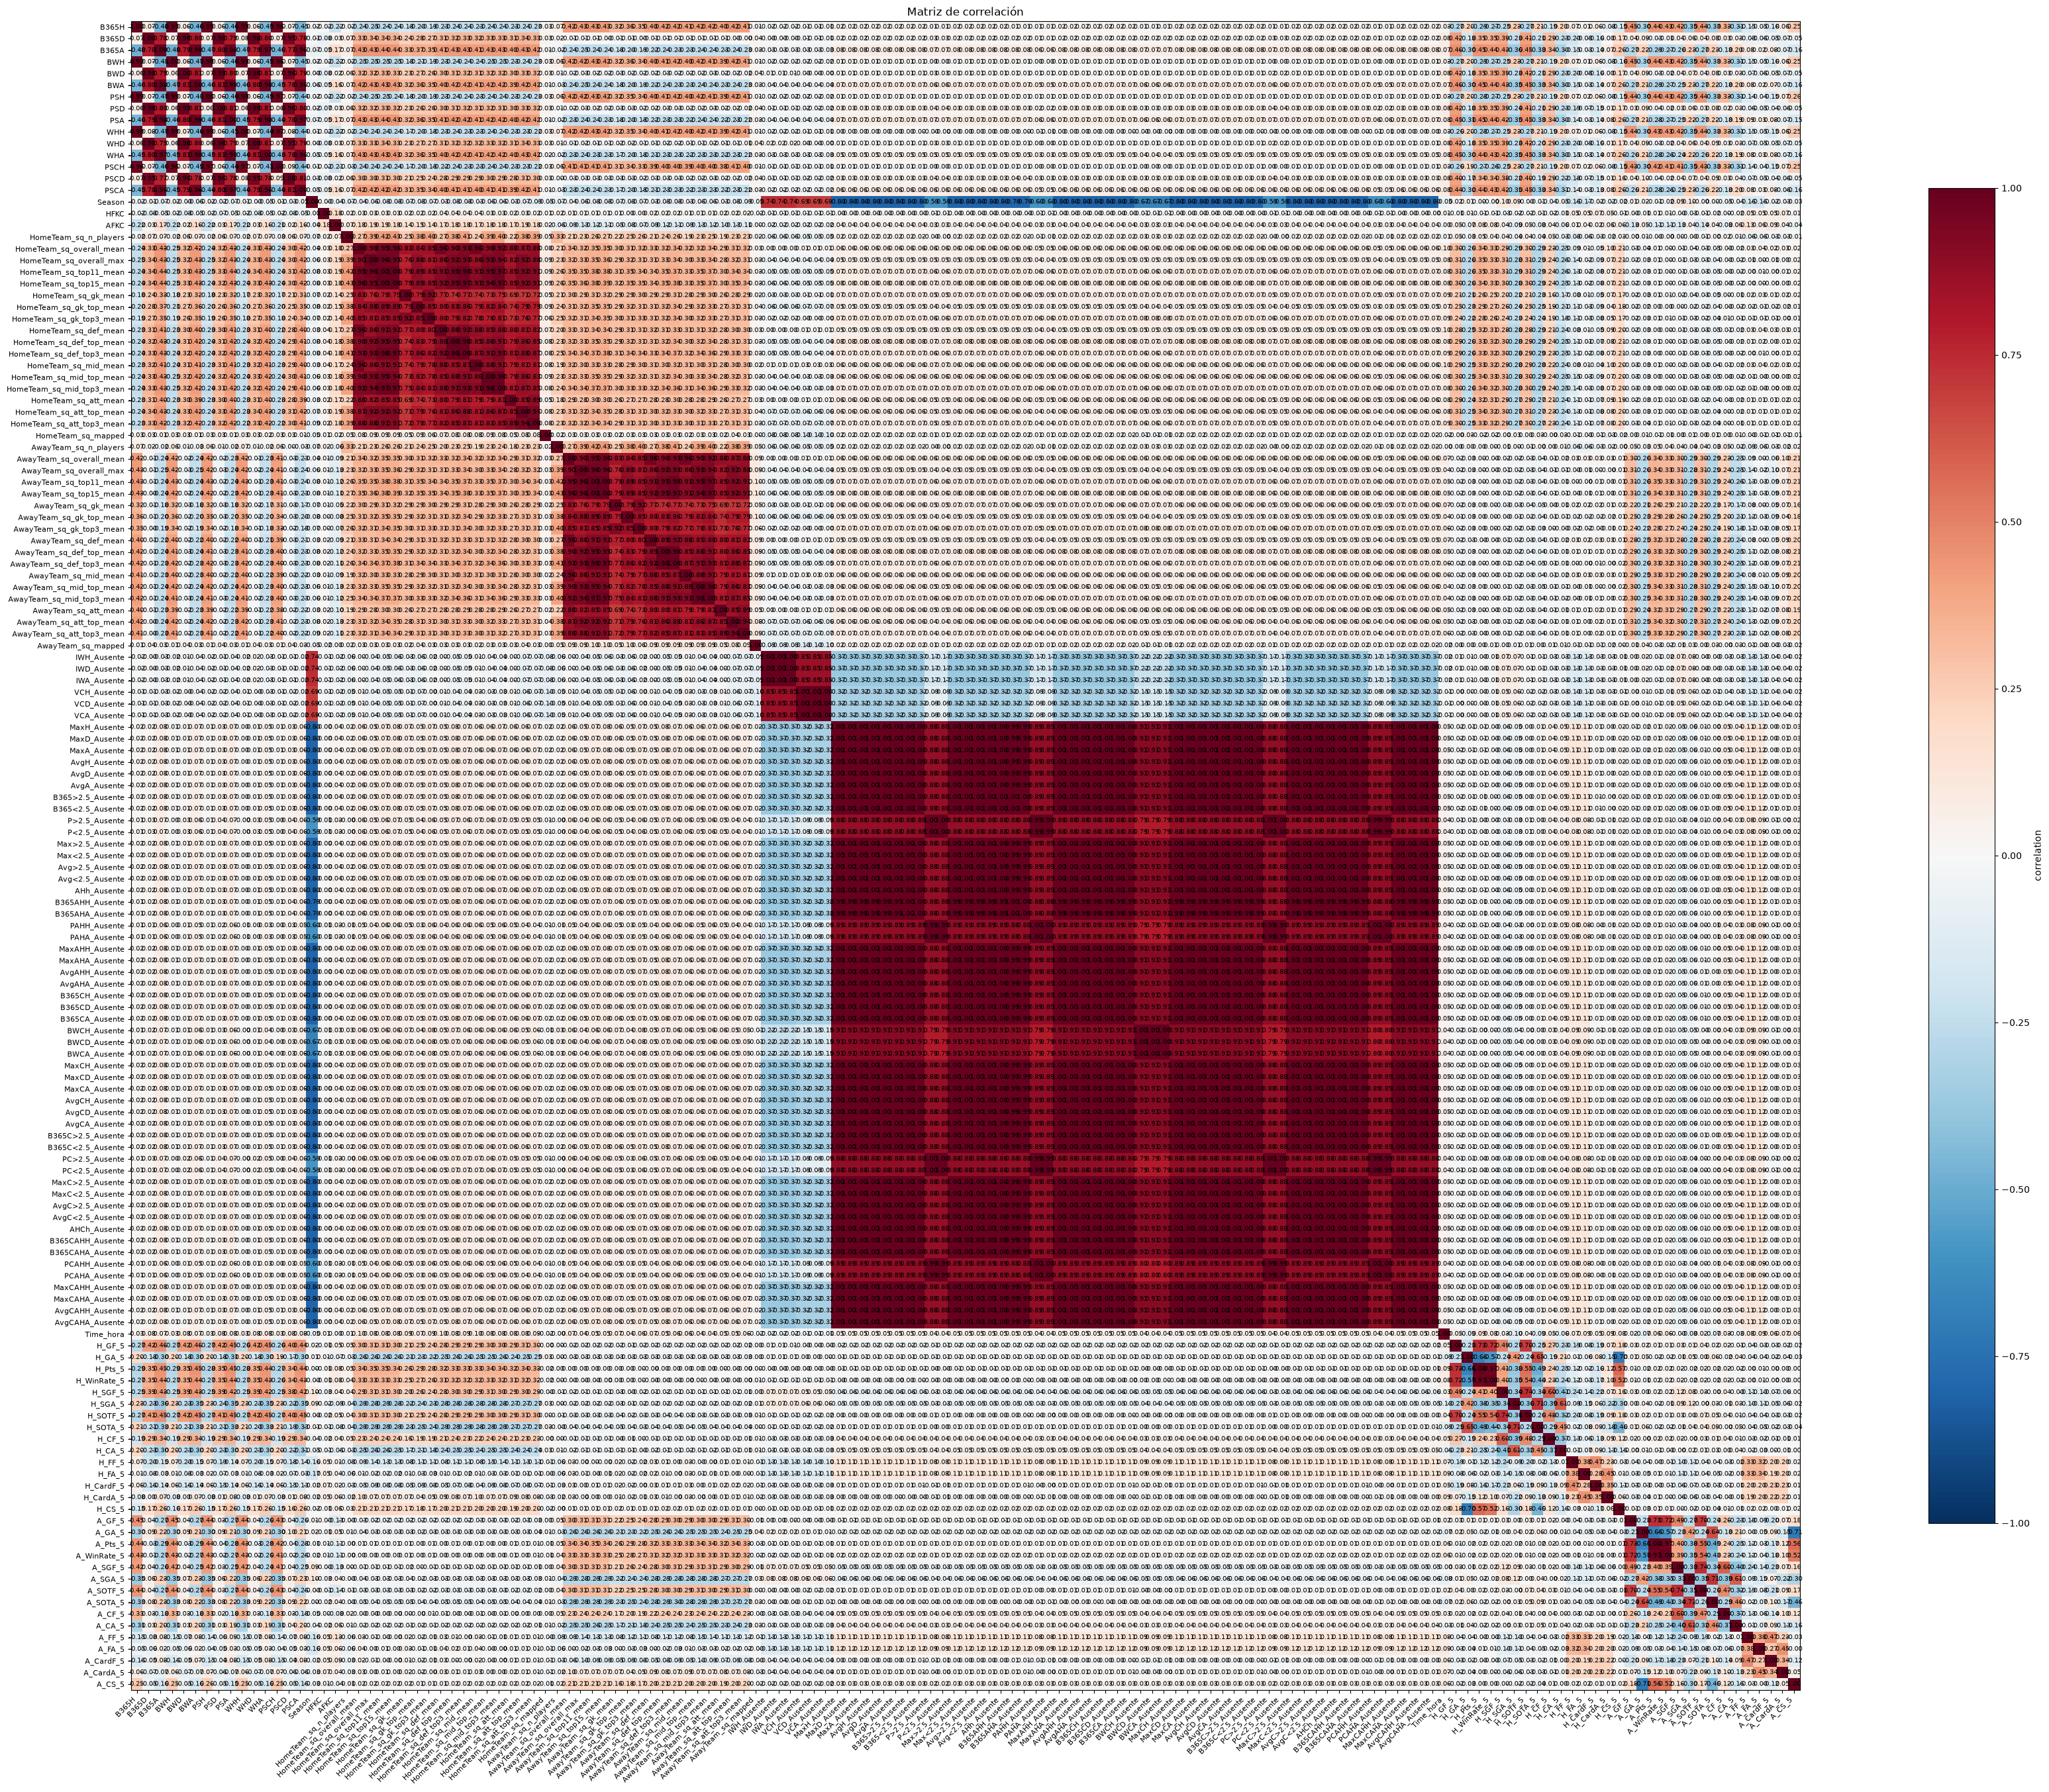

In [6]:
num = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[num].corr()
fig, ax = plt.subplots(figsize=(50, 40))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Matriz de correlación")
fig.subplots_adjust(bottom=0.25)
plt.show()

## Feature Engineer
En la mayoria de atributos de cuotas, notamos que las casas copian el mercado teniendo una correlación alta entre ellas, así que de todas los bloques conservamos únicamente la media del mercado: `AvgH`, `AvgD`, `AvgA`.

In [7]:
TARGET = 'FTR'
ID = ['Date', 'Date_dt', 'HomeTeam', 'AwayTeam', 'Div']
FEATURES = [c for c in df_clean.columns if c not in ID + [TARGET]]

df_final = df_clean[FEATURES + [TARGET, 'Date']].copy()
df_final['Date_dt'] = pd.to_datetime(df_final['Date'], dayfirst=True, errors='coerce')

cuotas_purge = [c for c in CUOTAS if c in df_final.columns and c not in ['AvgH', 'AvgD', 'AvgA']]
df_final = df_final.drop(columns=cuotas_purge)

AVG_ODDS = ['AvgH', 'AvgD', 'AvgA']
_sc = StandardScaler()
_X_s = _sc.fit_transform(df[AVG_ODDS])
_X_i = KNNImputer(n_neighbors=5).fit_transform(_X_s)
df_final[AVG_ODDS] = _sc.inverse_transform(_X_i)
print('df_final:', df_final.shape, '| cuotas eliminadas:', len(cuotas_purge), '| AvgH/D/A recuperadas: OK')

/tmp/ipykernel_145533/3769700835.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final['Date_dt'] = pd.to_datetime(df_final['Date'], dayfirst=True, errors='coerce')


df_final: (30182, 135) | cuotas eliminadas: 15 | AvgH/D/A recuperadas: OK


In [7]:
UMBRAL_CORR = 0.95
corte = df_final['Date_dt'].quantile(0.80)
train_idx = df_final['Date_dt'] <= corte

NUM_FEAT = [c for c in df_final.columns if c not in [TARGET, 'Date', 'Date_dt']
            and pd.api.types.is_numeric_dtype(df_final[c])]
corr_m = df_final.loc[train_idx, NUM_FEAT].corr().abs()

order = (['AvgH', 'AvgD', 'AvgA', 'Time_hora',
          'HomeTeam_sq_top11_mean', 'AwayTeam_sq_top11_mean']
         + sorted([c for c in NUM_FEAT if c.startswith(('H_', 'A_'))])
         + sorted([c for c in NUM_FEAT if c not in ['AvgH', 'AvgD', 'AvgA', 'Time_hora',
                   'HomeTeam_sq_top11_mean', 'AwayTeam_sq_top11_mean']
                   and not c.startswith(('H_', 'A_'))]))

kept, dropped = [], set()
for c in order:
    if c not in corr_m.columns or c in dropped:
        continue
    kept.append(c)
    for d in NUM_FEAT:
        r = corr_m.loc[c, d]
        if d not in kept and d not in dropped and not (r != r) and r > UMBRAL_CORR:
            dropped.add(d)

drop_list = [d for d in dropped if d in df_final.columns]
df_final = df_final.drop(columns=drop_list)
print('eliminadas por correlación:', len(drop_list))

eliminadas por correlación: 67


## Squad:
Del bloque squad nos quedamos **solo con la media global del 11 inicial** (`top11_mean`): las medias por línea
(def/mid/att/top3…) tiene una correlacion de 0.88–0.96 con top11 y no aportan, entonces las eliminamos. Además, para el
resultado importa más la **ventaja neta** sobre el rival que el valor absoluto: creamos `DIF_sq_top11 = local − visitante`
y quitamos la absoluta del visitante (queda representada por la diferencia + la del local). Los flags `_mapped` se
conservan (marcan slots sin squad imputados).

In [8]:
KEEP_SQ = {'HomeTeam_sq_top11_mean', 'AwayTeam_sq_top11_mean',
           'HomeTeam_sq_mapped', 'AwayTeam_sq_mapped'}
sq_drop = [c for c in df_final.columns if '_sq_' in c and c not in KEEP_SQ]
df_final = df_final.drop(columns=sq_drop)

df_final['DIF_sq_top11'] = df_final['HomeTeam_sq_top11_mean'] - df_final['AwayTeam_sq_top11_mean']
df_final = df_final.drop(columns=['AwayTeam_sq_top11_mean'])
print('squad granulares eliminadas:', len(sq_drop))
print('squad restantes:', [c for c in df_final.columns if '_sq_' in c or c.startswith('DIF_sq_')])

squad granulares eliminadas: 22
squad restantes: ['HomeTeam_sq_top11_mean', 'HomeTeam_sq_mapped', 'AwayTeam_sq_mapped', 'DIF_sq_top11']


## Mutual Information
`mutual_info_classif` es una función que mide cuánta información aporta cada feature para predecir `FTR` (no es lineal, a diferencia de la correlación). Se calcula **solo en train** y conservamos el **top 40**: corta flags/ruido sin aporte.

In [9]:
from sklearn.feature_selection import mutual_info_classif

NUM_FEAT = [c for c in df_final.columns if c not in [TARGET, 'Date', 'Date_dt']
            and pd.api.types.is_numeric_dtype(df_final[c])]
y_cod = df_final.loc[train_idx, TARGET].map({'H': 0, 'D': 1, 'A': 2}).astype(int)

mi = mutual_info_classif(df_final.loc[train_idx, NUM_FEAT], y_cod, random_state=42, n_neighbors=3)
mi_serie = pd.Series(mi, index=NUM_FEAT).sort_values(ascending=False)

N_TOP = 40
keep_mi = list(mi_serie.head(N_TOP).index)
df_final = df_final[keep_mi + [TARGET, 'Date', 'Date_dt']]
print('Top 40 por Mutual Information:')
print(mi_serie.head(40).round(4).to_string())

Top 40 por Mutual Information:
AvgA                      0.0683
DIF_sq_top11              0.0649
AvgH                      0.0641
HomeTeam_sq_top11_mean    0.0296
A_GF_5                    0.0279
A_Pts_5                   0.0276
A_SGF_5                   0.0189
H_GF_5                    0.0185
H_SGA_5                   0.0181
AvgD                      0.0172
H_SGF_5                   0.0170
H_SOTF_5                  0.0168
A_SOTF_5                  0.0166
H_Pts_5                   0.0159
A_SOTA_5                  0.0157
A_CS_5                    0.0148
H_CA_5                    0.0144
H_SOTA_5                  0.0124
H_CF_5                    0.0121
A_CF_5                    0.0114
A_CA_5                    0.0114
A_SGA_5                   0.0107
A_GA_5                    0.0097
HomeTeam_sq_mapped        0.0095
H_GA_5                    0.0093
A_FA_5                    0.0057
A_CardA_5                 0.0053
H_CS_5                    0.0041
VCA_Ausente               0.0028
Season      

## Verificación final

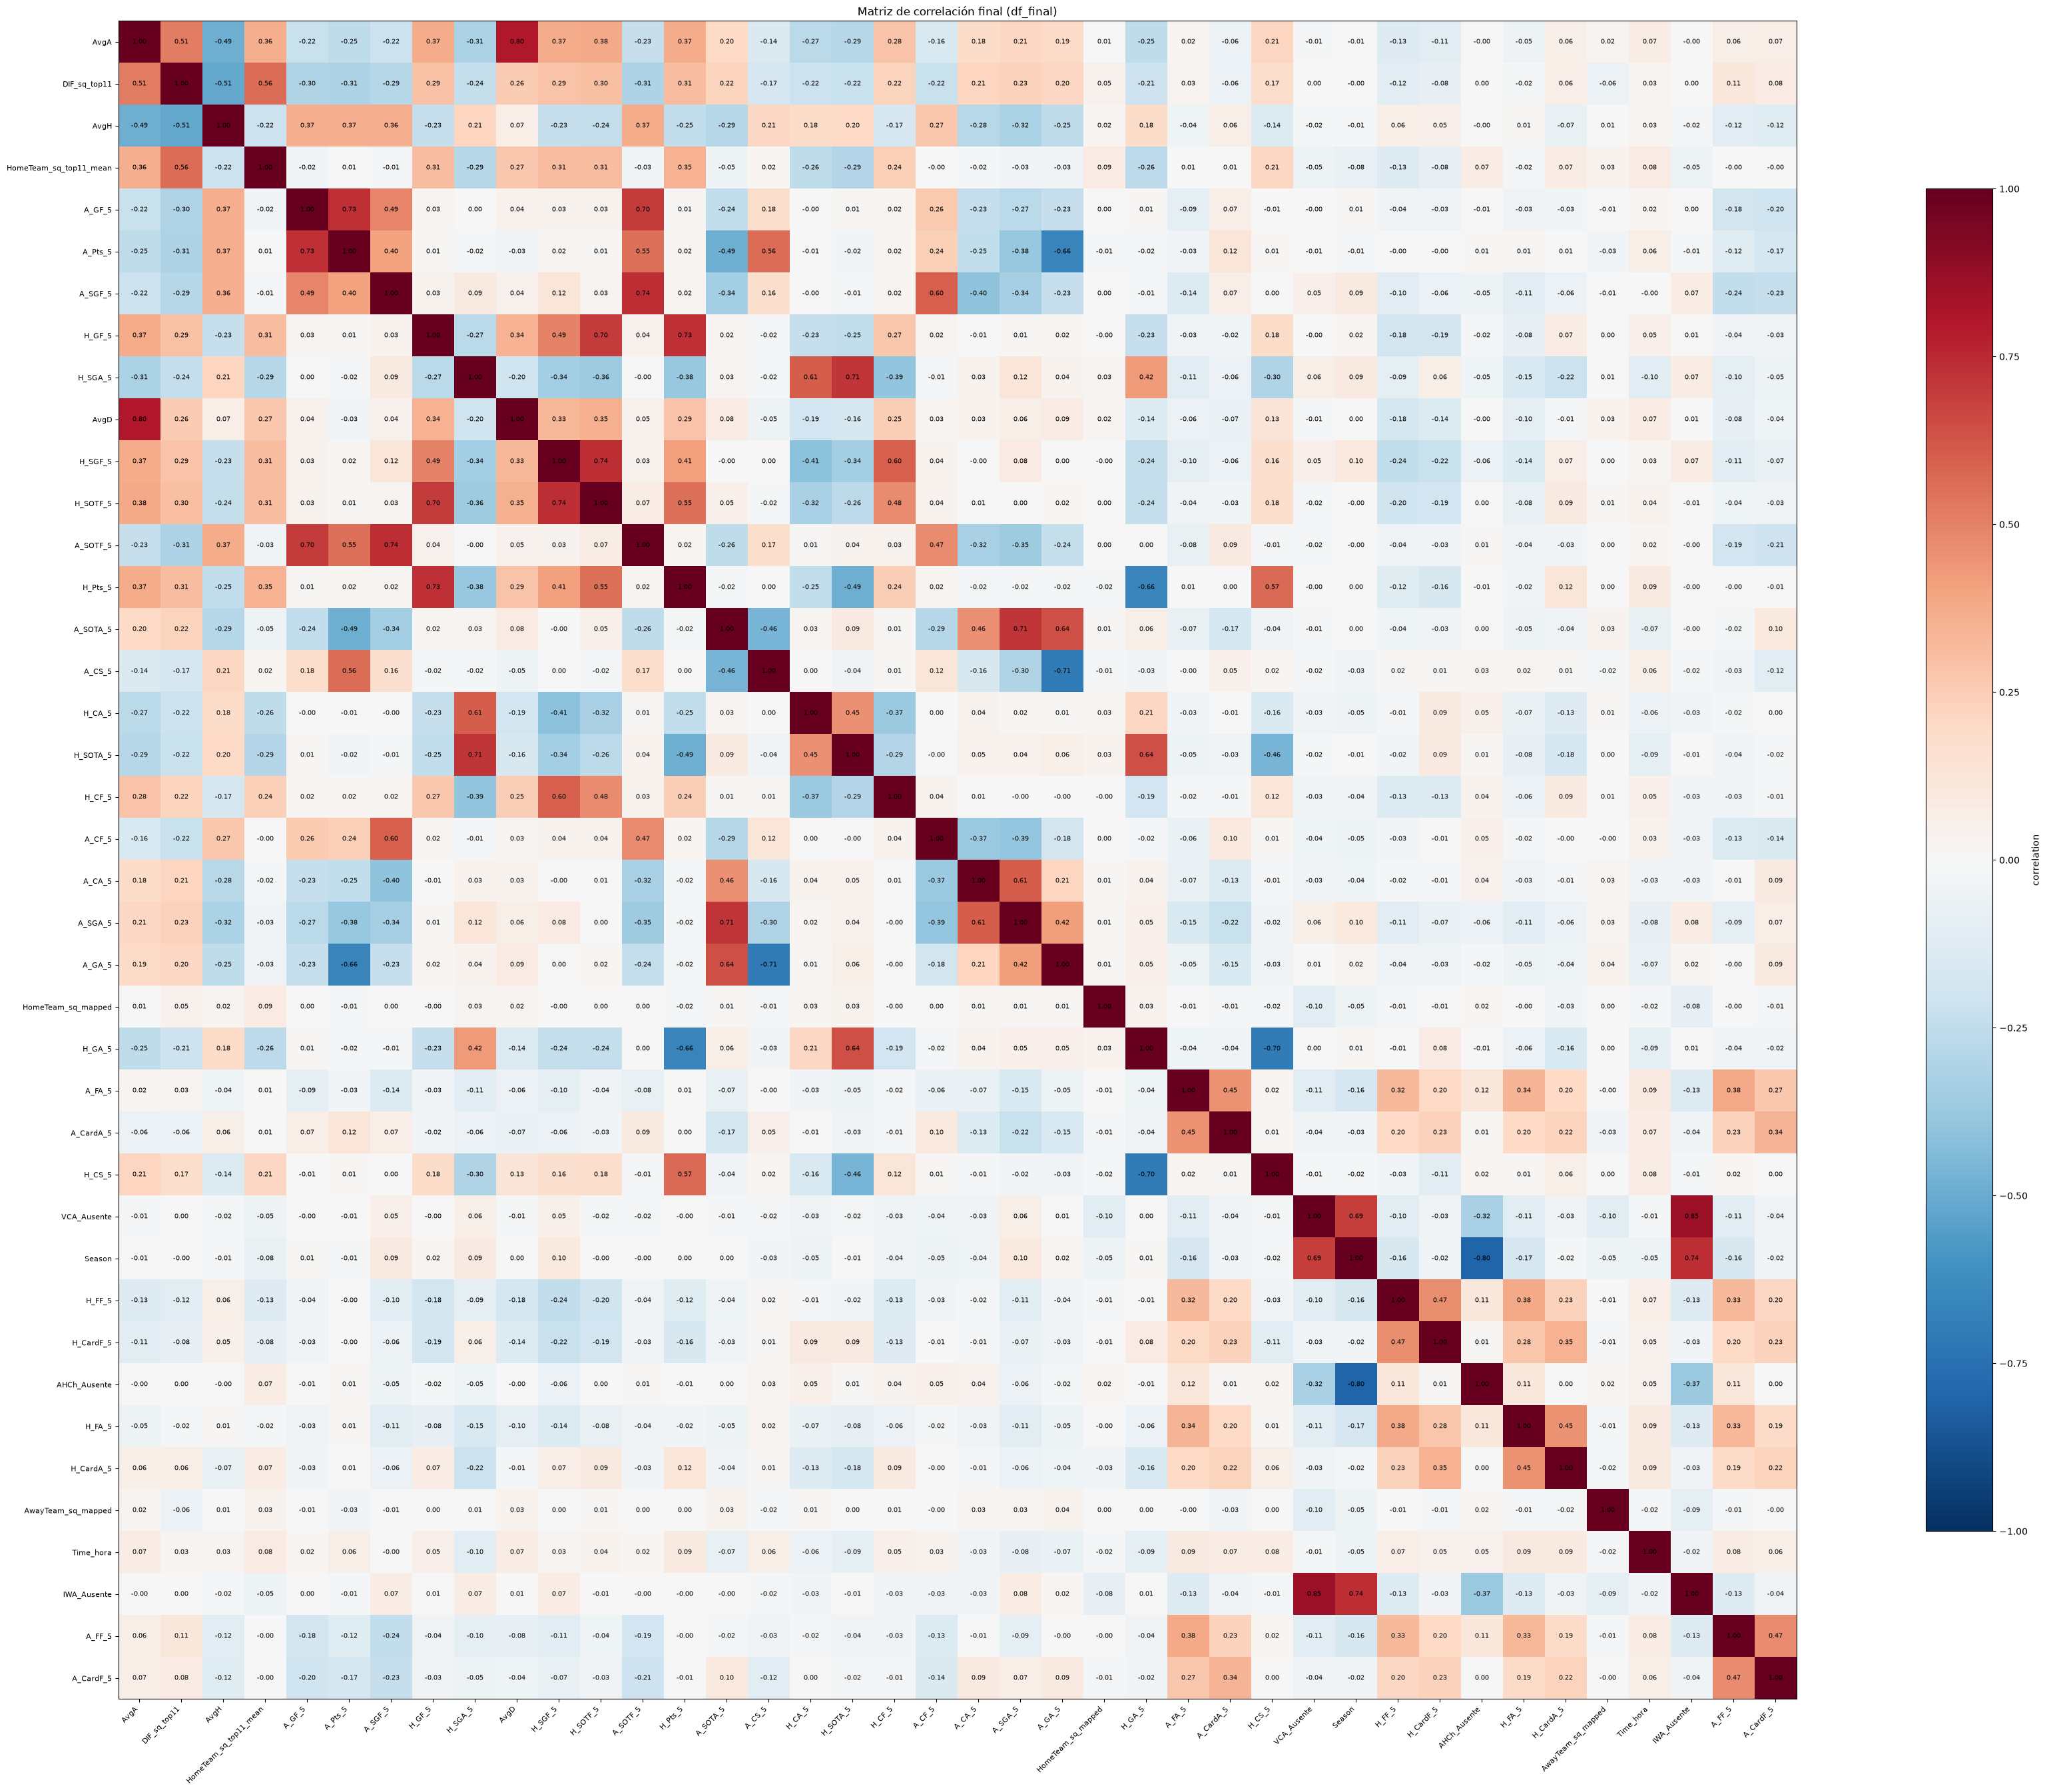

In [10]:
FEATURES = [c for c in df_final.columns if c not in [TARGET, 'Date', 'Date_dt']]
corr = df_final[FEATURES].corr()
fig, ax = plt.subplots(figsize=(50, 40))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label='correlation')
ax.set_title('Matriz de correlación final (df_final)')
fig.subplots_adjust(bottom=0.25)
plt.show()

In [11]:
df_final.to_csv("../scripts/data/dataset_final.csv", index=False)